<img src="https://miro.medium.com/v2/resize:fit:1400/1*zomnCz8-VMgrSV8eLCx2tw.gif" width="200" alt="molecula"  />

$$\Large \textit{Cuaderno de Código #5 | Sesión Nº 6}$$

---
$$\large\textbf{Optimización de hiperparámetros}$$

---
$$\textit{Curso: IA desde Cero}$$

<br>
<br>

__Dr. Jesus Alvarado-Huayhuaz__

# 1. Requerimientos

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Datos

In [24]:
"""
from sklearn.datasets import load_iris
data = load_iris()
X = data.data
y = data.target
"""
"""
from sklearn.datasets import load_wine
data = load_wine()
X = data.data
y = data.target
"""

from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Entrenamiento

In [26]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Métricas

In [27]:
y_pred = model.predict(X_test)
print('Exactitud:', accuracy_score(y_test, y_pred))
print('Matriz de confusión:\n', confusion_matrix(y_test, y_pred))
print('Reporte de clasificación:\n', classification_report(y_test, y_pred))

Exactitud: 0.9707602339181286
Matriz de confusión:
 [[ 59   4]
 [  1 107]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



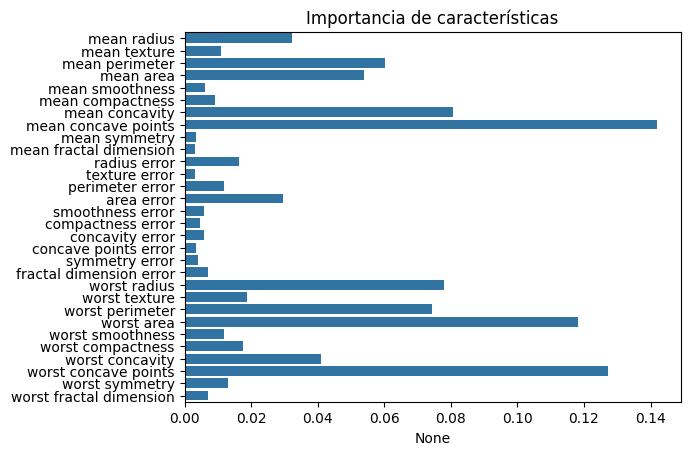

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_importances = pd.Series(model.feature_importances_, index=data.feature_names)
sns.barplot(x=feat_importances, y=data.feature_names)
plt.title('Importancia de características')
plt.show()

# 5. Optimización de hiperparámetros

In [29]:
from sklearn.model_selection import GridSearchCV

In [30]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [31]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=2)

In [32]:
grid_search.fit(X_train, y_train)
print('Mejores parámetros:', grid_search.best_params_)
print('Mejor precisión:', grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Mejor precisión: 0.9572468354430379


| **Hiperparámetro**       | **Valores probados** | **Descripción**                                            | **Efecto principal en el modelo**                                                            |
| ------------------------ | -------------------- | ---------------------------------------------------------- | -------------------------------------------------------------------------------------------- |
| `n_estimators`           | [50, 100, 200]       | Número de árboles en el bosque.                            | Más árboles pueden mejorar la precisión, pero aumentan el tiempo de cómputo.                 |
| `max_depth`              | [None, 5, 10, 20]    | Profundidad máxima de cada árbol.                          | Controla el sobreajuste: valores altos pueden sobreajustar; valores bajos pueden subajustar. |
| `min_samples_split`      | [2, 5, 10]           | Mínimo número de muestras necesarias para dividir un nodo. | Valores mayores reducen el sobreajuste al hacer árboles más “generales”.                     |
| `min_samples_leaf`       | [1, 2, 4]            | Mínimo número de muestras en una hoja.                     | Evita hojas muy pequeñas y reduce el sobreajuste.                                            |
| `random_state`           | 42 (fijo)            | Semilla para reproducibilidad de los resultados.           | No afecta el rendimiento, pero asegura que los resultados sean reproducibles.                |
| `cv` (en `GridSearchCV`) | 5                    | Número de particiones en validación cruzada.               | Mejora la estimación del rendimiento al promediar sobre varias divisiones.                   |


# 6. Nuevo Entrenamiento

Entrenando el modelo con los mejores parámetros

In [34]:
# Entrenar el mejor modelo encontrado por GridSearchCV
best_model = grid_search.best_estimator_

# Entrenamos el modelo con los mejores parámetros
best_model.fit(X_train, y_train)

# Realizamos predicciones con el modelo optimizado
y_pred_best = best_model.predict(X_test)

# Evaluamos su desempeño
print("Exactitud del modelo optimizado:", accuracy_score(y_test, y_pred_best))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_best))
print("Reporte de clasificación:\n", classification_report(y_test, y_pred_best))


Exactitud del modelo optimizado: 0.9707602339181286
Matriz de confusión:
 [[ 59   4]
 [  1 107]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



# 7. Nuevos Modelos

Exploración de otros modelos

In [12]:
# Instalamos la librería (si no está instalada)
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.6/752.6 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 20.0 MB/s eta 0:00:00


In [35]:
# Importamos LazyPredict
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split

# Dividimos los datos (si aún no lo hiciste)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Inicializamos el objeto LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

In [36]:
# Ejecutamos la comparación
%%capture
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

In [37]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LogisticRegression,0.98,0.98,0.98,0.98,0.03
Perceptron,0.98,0.98,0.98,0.98,0.02
LinearSVC,0.98,0.98,0.98,0.98,0.02
PassiveAggressiveClassifier,0.98,0.97,0.97,0.98,0.02
SVC,0.98,0.97,0.97,0.98,0.04
ExtraTreesClassifier,0.98,0.97,0.97,0.98,0.17
CalibratedClassifierCV,0.98,0.97,0.97,0.98,0.06
AdaBoostClassifier,0.97,0.97,0.97,0.97,0.25
SGDClassifier,0.96,0.97,0.97,0.97,0.02


# 8. Otros datasets de ejemplo

| **Dataset (de `sklearn.datasets`)** | **Tipo de problema** | **Descripción**                                                    | **Código para cargarlo**                                                                       |
| ----------------------------------- | -------------------- | ------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------- |
| **Wine**                            | Clasificación        | Clasifica tipos de vino según análisis químico.                    | `from sklearn.datasets import load_wine`<br>`data = load_wine()`                               |
| **Breast Cancer**                   | Clasificación        | Detecta si un tumor es benigno o maligno a partir de mediciones.   | `from sklearn.datasets import load_breast_cancer`<br>`data = load_breast_cancer()`             |
| **Digits**                          | Clasificación        | Reconocimiento de dígitos escritos a mano (0–9).                   | `from sklearn.datasets import load_digits`<br>`data = load_digits()`                           |
| **Diabetes**                        | Regresión            | Predice la progresión de la diabetes a partir de medidas clínicas. | `from sklearn.datasets import load_diabetes`<br>`data = load_diabetes()`                       |
| **California Housing**              | Regresión            | Predice el valor medio de las viviendas en California.             | `from sklearn.datasets import fetch_california_housing`<br>`data = fetch_california_housing()` |


# 9. Modelos de Regresión

| **Métrica** | **Significado**                 | **Interpretación**                                                                                      |
| ----------- | ------------------------------- | ------------------------------------------------------------------------------------------------------- |
| `R²`        | Coeficiente de determinación    | Cuánto del comportamiento de la variable dependiente se explica por el modelo (más cerca de 1 = mejor). |
| `MAE`       | Error absoluto medio            | Promedio de los errores absolutos; más bajo = mejor.                                                    |
| `RMSE`      | Raíz del error cuadrático medio | Penaliza errores grandes; más bajo = mejor.                                                             |


La siguiente celda tarda considerablemente, ejecutar con prudencia.

R² (coeficiente de determinación): 0.8045734925119942
MAE (error absoluto medio): 0.33228759407299757
RMSE (raíz del error cuadrático medio): 0.5064633542597075


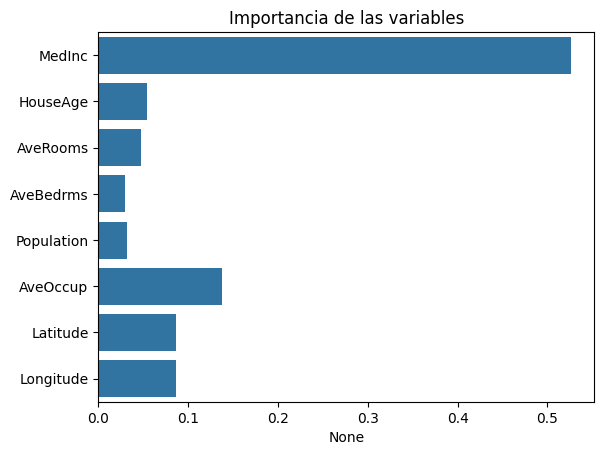

Fitting 3 folds for each of 108 candidates, totalling 324 fits


In [ ]:
# 1️⃣ Importar librerías
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# 2️⃣ Cargar el dataset
data = fetch_california_housing()
X = data.data
y = data.target

# 3️⃣ Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4️⃣ Entrenar modelo base
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5️⃣ Evaluar desempeño inicial
y_pred = model.predict(X_test)

print("R² (coeficiente de determinación):", r2_score(y_test, y_pred))
print("MAE (error absoluto medio):", mean_absolute_error(y_test, y_pred))
print("RMSE (raíz del error cuadrático medio):", np.sqrt(mean_squared_error(y_test, y_pred)))

# 6️⃣ Visualizar importancia de variables
feat_importances = pd.Series(model.feature_importances_, index=data.feature_names)
sns.barplot(x=feat_importances, y=data.feature_names)
plt.title("Importancia de las variables")
plt.show()

# 7️⃣ Optimización de hiperparámetros con GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor R² promedio (cross-validation):", grid_search.best_score_)

# 8️⃣ Evaluar modelo optimizado
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\n🔹 Desempeño del modelo optimizado:")
print("R²:", r2_score(y_test, y_pred_best))
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))